In [28]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [4]:
df=pd.read_csv("Titanic Dataset.csv")
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [6]:
df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [7]:
df.isna().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,263
sibsp,0
parch,0
ticket,0
fare,1
cabin,1014


In [8]:
df['age']=df['age'].fillna(df['age'].mean())
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])

In [9]:
df=df.drop(['fare','cabin','boat','body','home.dest'],axis=1)

In [10]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.000000,0,0,24160,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.920000,1,2,113781,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.000000,1,2,113781,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.000000,1,2,113781,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.000000,1,2,113781,S
...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.500000,1,0,2665,C
1305,3,0,"Zabour, Miss. Thamine",female,29.881138,1,0,2665,C
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.500000,0,0,2656,C
1307,3,0,"Zakarian, Mr. Ortin",male,27.000000,0,0,2670,C


In [11]:
df['sex']=df['sex'].map({'male':0,'female':1})
df['embarked']=df['embarked'].map({'S':0,'C':1,'Q':2})

In [12]:
df=df.drop(['name','sibsp','parch','ticket'],axis=1)

In [13]:
df

,pclass,survived,sex,age,embarked
0,1,1,1,29.000000,0
1,1,1,0,0.920000,0
2,1,0,1,2.000000,0
3,1,0,0,30.000000,0
4,1,0,1,25.000000,0
...,...,...,...,...,...
1304,3,0,1,14.500000,1
1305,3,0,1,29.881138,1
1306,3,0,0,26.500000,1
1307,3,0,0,27.000000,1


In [14]:
X=df.drop('survived',axis=1)
y=df['survived']

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
model1=LogisticRegression()
model1.fit(X_train,y_train)
pred=model1.predict(X_test)
ac1=accuracy_score(y_test,pred)
print("Accuracy:",ac1)

Accuracy: 0.7748091603053435


In [23]:
model2=DecisionTreeClassifier()
model2.fit(X_train,y_train)
pred=model2.predict(X_test)
ac2=accuracy_score(y_test,pred)
print("Accuracy:",ac2)

Accuracy: 0.7213740458015268


In [24]:
model3=RandomForestClassifier()
model3.fit(X_train,y_train)
pred=model3.predict(X_test)
ac3=accuracy_score(y_test,pred)
print("Accuracy:",ac3)

Accuracy: 0.7366412213740458


In [25]:
cm=confusion_matrix(y_test,pred)
cm
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.72      0.85      0.78       144
           1       0.77      0.59      0.67       118

    accuracy                           0.74       262
   macro avg       0.74      0.72      0.73       262
weighted avg       0.74      0.74      0.73       262



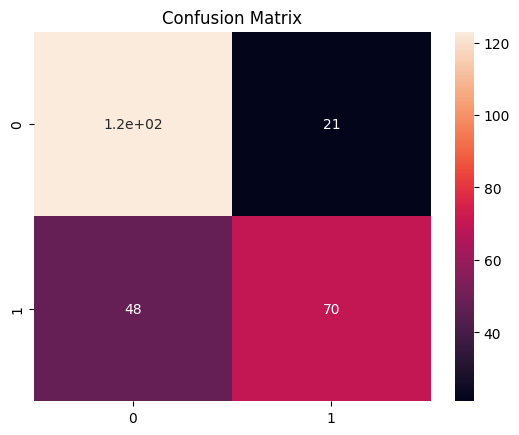

In [26]:
sns.heatmap(cm,annot=True)
plt.title("Confusion Matrix")
plt.show()

Logistic Regression performed better compared to other models, showing that a simpler model works well for this dataset


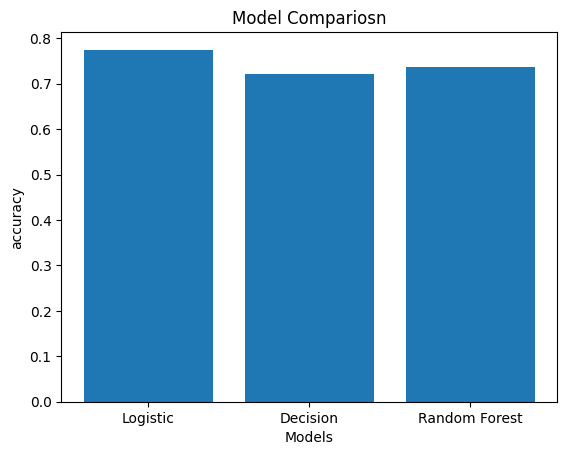

In [30]:
models=['Logistic','Decision','Random Forest']
ac=[ac1,ac2,ac3]
plt.bar(models,ac)
plt.xlabel("Models")
plt.ylabel("accuracy")
plt.title("Model Compariosn")
plt.show()

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities
y_prob = model.predict_proba(X_test)[:,1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# AUC Score
print("AUC Score:", roc_auc_score(y_test, y_prob))

NameError: name 'model' is not defined